# Final Project ML and DL

## Machine Learning and Deep Learning (CDSCO2041C)

**Group Members:**

- Torjus Arne Ljungqvist (S161489)
- Jan Henrik Haudemann-Andersen (S162647)
- Sebastian Nes Romero (S185875)

---

# SAR Oil Spill Detection

---


# 0.Setup & Data Loading

Download the dataset from Kaggle and import all required libraries.


In [ ]:
# Uncomment if running in Google Colab with Drive / comment out if not using colab with drive
# from google.colab import drive
# drive.mount('/content/drive')

import kagglehub

path = kagglehub.dataset_download(
    "harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset"
)
print("Path to dataset files:", path)

100%|██████████| 65.3M/65.3M [00:03<00:00, 18.2MB/s]

Extracting files...


Path to dataset files: /Users/sebastianromero/.cache/kagglehub/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset/versions/1


In [86]:
# dependencies (uncomment if running for the first time)
# !pip install kagglehub pillow numpy pandas matplotlib scikit-learn tensorflow

In [2]:
import os
import hashlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

2026-05-01 09:39:10.164314: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# # # reprodusable results
# os.environ["TF_DETERMINISTIC_OPS"] = "1"
# os.environ["PYTHONHASHSEED"] = "42"
# tf.random.set_seed(42)
# np.random.seed(42)

# 1.Exploratory Data Analysis (EDA)


## 1.1 Build DataFrame

Scan both class folders and construct a single DataFrame with filepath and label columns.


In [ ]:
DATA_DIR = os.path.join(path, "data")
CLASS_0_DIR = os.path.join(DATA_DIR, "S1SAR_UnBalanced_400by400_Class_0", "0")
CLASS_1_DIR = os.path.join(DATA_DIR, "S1SAR_UnBalanced_400by400_Class_1", "1")


def load_class(directory, label):
    files = [
        os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(".jpg")
    ]
    return pd.DataFrame({"filepath": files, "label": label})


df = pd.concat(
    [load_class(CLASS_0_DIR, 0), load_class(CLASS_1_DIR, 1)], ignore_index=True
)
df["label_name"] = df["label"].map({0: "No Oil Spill", 1: "Oil Spill"})

print(f"Total images loaded : {len(df)}")
print(f"Columns: {list(df.columns)}")
print(df["label_name"].value_counts())
df.head()

Total images loaded : 5630
Columns: ['filepath', 'label', 'label_name']
No Oil Spill    3725
Oil Spill       1905
Name: label_name, dtype: int64


,filepath,label,label_name
0,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
1,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
2,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
3,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
4,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill


## 1.2 Class Distribution

Visualise how many images belong to each class. This is critical for a SAR dataset because oil spill events are rare, we expect a significant imbalance.


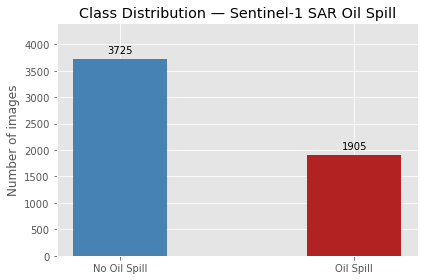

Class counts  : {'No Oil Spill': 3725, 'Oil Spill': 1905}
Imbalance ratio (No Oil Spill / Oil Spill): 1.96x


In [ ]:
counts = df["label_name"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=["steelblue", "firebrick"], width=0.4)
ax.bar_label(bars, padding=4)
ax.set_ylabel("Number of images")
ax.set_title("Class Distribution — Sentinel-1 SAR Oil Spill")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

ratio = counts["No Oil Spill"] / counts["Oil Spill"]
print(f"Class counts  : {dict(counts)}")
print(f"Imbalance ratio (No Oil Spill / Oil Spill): {ratio:.2f}x")

## 1.3 Sample Images per Class

Visually inspect a random selection of images from each class to understand what the SAR imagery data looks like.


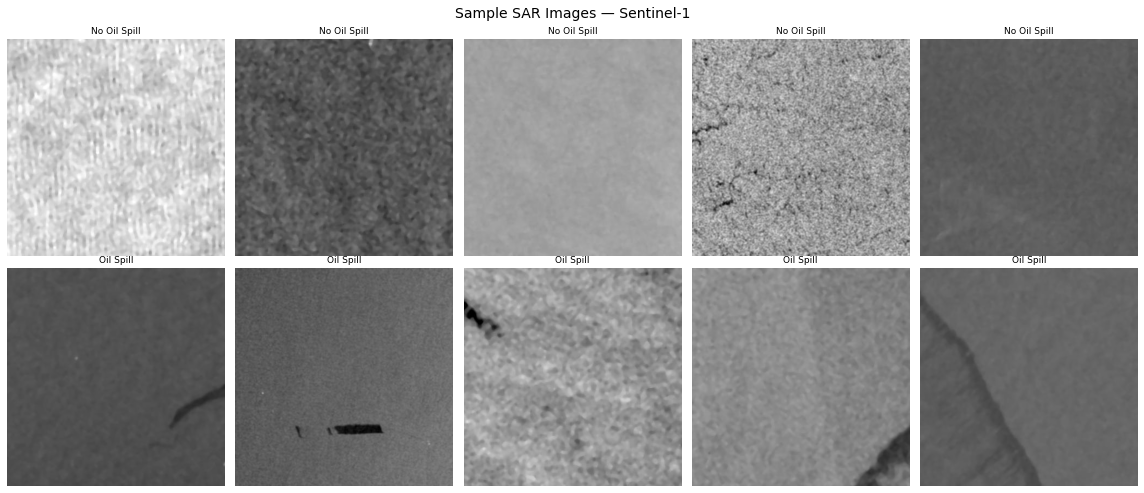

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Sample SAR Images — Sentinel-1", fontsize=14)

for i, ax in enumerate(axes[0]):
    fp = df[df["label"] == 0]["filepath"].iloc[i]
    ax.imshow(Image.open(fp))
    ax.set_title("No Oil Spill", fontsize=9)
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    fp = df[df["label"] == 1]["filepath"].iloc[i]
    ax.imshow(Image.open(fp))
    ax.set_title("Oil Spill", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1.4 Image Shape & Channel Verification

SAR data is physically single-channel (backscatter intensity), but JPEGs always store 3 channels. Confirming that all three RGB channels are identical tells us the images are grayscale stored as colour. Therefore we can safely collapse to 1 channel for the CNN.


In [7]:
sample_img = Image.open(df["filepath"].iloc[0])
arr = np.array(sample_img)

# check image stats/desc
print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode}")
print(f"Numpy array shape: {arr.shape}")

r_eq_g = np.array_equal(arr[:, :, 0], arr[:, :, 1])
r_eq_b = np.array_equal(arr[:, :, 0], arr[:, :, 2])
print(f"\nAll RGB channels identical: {r_eq_g and r_eq_b}")

# Confirm shape is consistent across a 100-image random sample
shapes = set()
for fp in df["filepath"].sample(100, random_state=42):
    shapes.add(np.array(Image.open(fp)).shape)
print(f"\nUnique shapes in 100-image sample: {shapes}")

Image size: (400, 400)
Image mode: RGB
Numpy array shape: (400, 400, 3)

All RGB channels identical: True



Unique shapes in 100-image sample: {(400, 400, 3)}


## 1.5 Pixel Intensity Distribution per Class

SAR backscatter values encode surface roughness and dielectric properties. Oil spills dampen surface roughness, so oil-covered areas typically appear **darker** (lower backscatter). We expect the Oil Spill class to have a lower mean intensity.


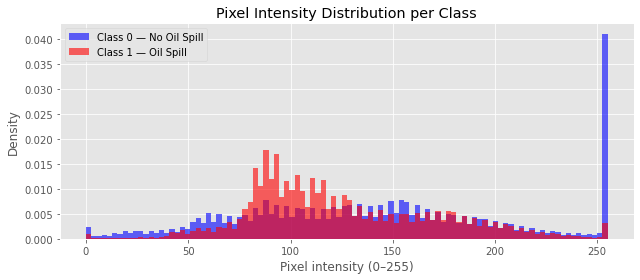

Class 0 (No Oil Spill) mean: 140.37,  std: 64.42
Class 1 (Oil Spill) mean: 124.75,  std: 45.49

Mean brightness difference (No Oil − Oil): 15.61 intensity units
Oil Spill images are darker on average, consistent with reduced SAR backscatter caused by oil dampening sea surface roughness.


In [8]:
def sample_pixel_values(filepaths, n=200, random_state=42):
    """Load a random sample of images and return a flat array of all pixel values."""
    values = []
    for fp in filepaths.sample(min(n, len(filepaths)), random_state=random_state):
        arr = np.array(Image.open(fp).convert("L"), dtype=np.float32)
        values.append(arr.ravel())
    return np.concatenate(values)


pixels_0 = sample_pixel_values(df[df["label"] == 0]["filepath"])
pixels_1 = sample_pixel_values(df[df["label"] == 1]["filepath"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    pixels_0,
    bins=100,
    alpha=0.6,
    color="blue",
    label="Class 0 — No Oil Spill",
    density=True,
)
ax.hist(
    pixels_1,
    bins=100,
    alpha=0.6,
    color="red",
    label="Class 1 — Oil Spill",
    density=True,
)
ax.set_xlabel("Pixel intensity (0–255)")
ax.set_ylabel("Density")
ax.set_title("Pixel Intensity Distribution per Class")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Class 0 (No Oil Spill) mean: {pixels_0.mean():.2f},  std: {pixels_0.std():.2f}")
print(f"Class 1 (Oil Spill) mean: {pixels_1.mean():.2f},  std: {pixels_1.std():.2f}")
print()
diff = pixels_0.mean() - pixels_1.mean()
print(f"Mean brightness difference (No Oil − Oil): {diff:.2f} intensity units")
print(
    "Oil Spill images are darker on average, consistent with reduced SAR backscatter caused by oil dampening sea surface roughness."
)

## 1.6 Brightness Outlier Detection (IQR Method)

Compute the mean pixel brightness of every image and flag outliers using the IQR rule (values outside Q1 − 1.5×IQR or Q3 + 1.5×IQR). Outliers are inspected visually to understand **why** they are extreme before deciding to remove them.


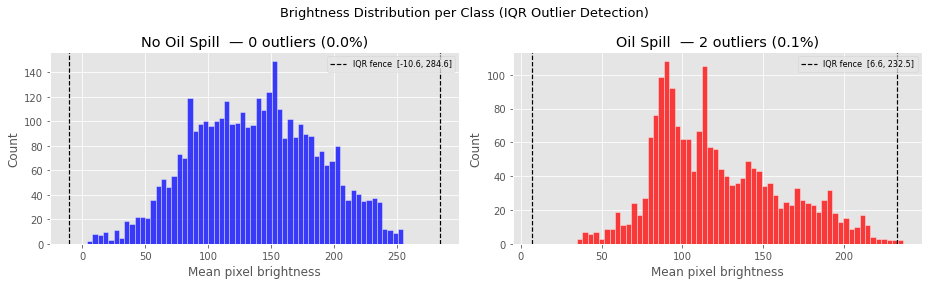

In [9]:
# Compute mean brightness for all images
df["mean_brightness"] = df["filepath"].apply(
    lambda fp: np.array(Image.open(fp).convert("L"), dtype=np.float32).mean()
)

# Plot brightness distributions with IQR bounds
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Brightness Distribution per Class (IQR Outlier Detection)", fontsize=13)

outlier_indices = []  # collect all outlier row indices across both classes

for ax, (label_val, label_name, color) in zip(
    axes, [(0, "No Oil Spill", "blue"), (1, "Oil Spill", "red")]
):
    subset = df[df["label"] == label_val]["mean_brightness"]
    q1, q3 = subset.quantile(0.25), subset.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_mask = (subset < lower) | (subset > upper)
    n_out = out_mask.sum()
    outlier_indices.extend(subset[out_mask].index.tolist())

    ax.hist(subset, bins=60, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(
        lower,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"IQR fence  [{lower:.1f}, {upper:.1f}]",
    )
    ax.axvline(upper, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(f"{label_name}  — {n_out} outliers ({n_out/len(subset)*100:.1f}%)")
    ax.set_xlabel("Mean pixel brightness")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 1.7 Inspect Outlier Images. What is Actually Wrong?

Rather than blindly removing outliers, we display and examine them. An outlier could be a near-black image (sensor dropout), a near-white image (specular reflection / system artefact), or a legitimately unusual but valid scene. Only images that are clearly artefacts or non-representative should be removed.


In [10]:
outlier_df = df.loc[outlier_indices].copy()
outlier_df["filename"] = outlier_df["filepath"].apply(os.path.basename)

outlier_df[["filename", "label_name", "mean_brightness"]].sort_values(
    "mean_brightness"
).reset_index(drop=True)

,filename,label_name,mean_brightness
0,348_3000_2000_img_UQDD8Igu5m0vkVY4_SIN_cls_1.jpg,Oil Spill,234.103302
1,568_3600_3200_img_kMrjI0CyUeY8Cc8P_GBR_cls_1.jpg,Oil Spill,236.543900


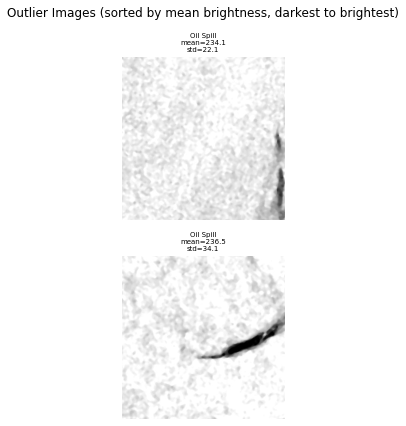

In [ ]:
# Sort by brightness so we see darkest and brightest
outlier_df_sorted = outlier_df.sort_values("mean_brightness").reset_index(drop=True)
n_show = min(len(outlier_df_sorted), 10)

fig, axes = plt.subplots(2, max(n_show // 2, 1), figsize=(16, 6))
axes = axes.ravel()
fig.suptitle(
    "Outlier Images (sorted by mean brightness, darkest to brightest)", fontsize=12
)

for i, (_, row) in enumerate(outlier_df_sorted.head(n_show).iterrows()):
    img = Image.open(row["filepath"]).convert("L")
    arr = np.array(img, dtype=np.float32)
    axes[i].imshow(arr, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(
        f"{row['label_name']}\n"
        f"mean={row['mean_brightness']:.1f}\n"
        f"std={arr.std():.1f}",
        fontsize=7,
    )
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [12]:
df.head()

,filepath,label,label_name,mean_brightness
0,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill,211.562149
1,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill,86.608917
2,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill,160.702652
3,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill,155.042038
4,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill,92.288322


In [13]:
df = df.drop(columns=["mean_brightness"])
df.columns

Index(['filepath', 'label', 'label_name'], dtype='object')

## 1.8 Descriptive Statistics per Class

Summarise key pixel-level statistics for both classes in a single table.


In [ ]:
stats = {
    "No Oil Spill": {
        "N images": len(df[df["label"] == 0]),
        "Mean pixel": f"{pixels_0.mean():.2f}",
        "Std pixel": f"{pixels_0.std():.2f}",
        "Median pixel": f"{np.median(pixels_0):.2f}",
        "Min pixel": f"{pixels_0.min():.2f}",
        "Max pixel": f"{pixels_0.max():.2f}",
    },
    "Oil Spill": {
        "N images": len(df[df["label"] == 1]),
        "Mean pixel": f"{pixels_1.mean():.2f}",
        "Std pixel": f"{pixels_1.std():.2f}",
        "Median pixel": f"{np.median(pixels_1):.2f}",
        "Min pixel": f"{pixels_1.min():.2f}",
        "Max pixel": f"{pixels_1.max():.2f}",
    },
}

stats_df = pd.DataFrame(stats).T
print("Descriptive Statistics per Class")
stats_df

Descriptive Statistics per Class


,N images,Mean pixel,Std pixel,Median pixel,Min pixel,Max pixel
No Oil Spill,3725,140.37,64.42,137.00,0.00,255.00
Oil Spill,1905,124.75,45.49,114.00,0.00,255.00


---
# 2.Filtering & Quality Control

Before training, we remove images that could corrupt the model's learning signal:
1. **Corrupt images** — unreadable files that would crash the data loader
2. **Exact duplicates** — identical images (MD5 hash) that would leak across splits
---


## 2.1 Corrupt Image Detection

Try to open and verify every file with PIL. Any file that raises an exception is unreadable and must be removed.


In [ ]:
corrupted = []
for fp in df["filepath"]:
    try:
        img = Image.open(fp)
        img.verify()  # checks file integrity without fully decoding
    except Exception as e:
        corrupted.append((fp, str(e)))

print(f"Corrupted images found: {len(corrupted)}")

Corrupted images found: 0


## 2.2 Duplicate Detection via MD5 Hash

Two images can have different filenames but identical pixel content. If a duplicate image ends up in both train and test splits, the model has effectively "seen" that test sample, inflating evaluation metrics. MD5 hashing detects exact byte-level duplicates.


In [ ]:
def file_hash(fp):
    with open(fp, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


df["hash"] = df["filepath"].apply(file_hash)
n_before = len(df)

duplicate_mask = df.duplicated(subset="hash", keep=False)
duplicates = df[duplicate_mask].copy()
print(f"Total images involved in duplicate groups: {len(duplicates)}")

if len(duplicates) > 0:
    print("\n--- Duplicate groups (images with identical MD5 hash) ---")
    dup_groups = (
        duplicates.assign(filename=duplicates["filepath"].apply(os.path.basename))
        .groupby("hash")[["filename", "label_name"]]
        .apply(lambda g: g.to_dict(orient="list"))
    )
    for h, group in dup_groups.items():
        print(f"  Hash: {h[:12]}...")
        for fname, lname in zip(group["filename"], group["label_name"]):
            print(f"    {lname}  {fname}")

    # Identify cross-class duplicate hashes
    cross_class_labels = df.groupby("hash")["label"].nunique()
    cross_class_hashes = set(cross_class_labels[cross_class_labels > 1].index)
    n_cross = len(cross_class_hashes)

    # Drop ALL rows for cross-class hashes first
    df = df[~df["hash"].isin(cross_class_hashes)]
    n_after_cross = len(df)
    print(f"Removed: {n_before - n_after_cross} cross-class duplicate row(s)")

    # Then deduplicate same-class duplicates, keeping first
    df = df.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)

df = df.drop(columns="hash")

Total images involved in duplicate groups: 183

--- Duplicate groups (images with identical MD5 hash) ---
  Hash: 057b9964af3d...
    No Oil Spill  759_1400_3400_img_eoXofrDXtXtQJbeP_GBR_cls_0.jpg
    No Oil Spill  759_1400_3400_img_4sMDG7GNlsre94cv_GBR_cls_0.jpg
  Hash: 09dee91cdf68...
    Oil Spill  4_0_200_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
    Oil Spill  4_0_200_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
  Hash: 0afb0647e6a8...
    No Oil Spill  0_0_0_img_SCoVQ72iCMzSlCo5_CHS_cls_0.jpg
    No Oil Spill  1_200_0_img_SCoVQ72iCMzSlCo5_CHS_cls_0.jpg
  Hash: 0e8ecea59fb3...
    Oil Spill  2262_7200_8000_img_hvCHRmIjOteATN6E_SIN_cls_1.jpg
    Oil Spill  2262_7200_8000_img_K8W3DHW5U6G4if3p_SIN_cls_1.jpg
  Hash: 0f4b4cae70e5...
    No Oil Spill  1003_9000_4600_img_wSSWghnw6sYLldf5_GBR_cls_0.jpg
    No Oil Spill  1003_9000_4600_img_bG0bhW5H3Xb9B3JU_GBR_cls_0.jpg
  Hash: 11048ad2e31e...
    Oil Spill  1963_11600_7800_img_TIuV1ihRBvOaEGoS_GBR_cls_1.jpg
    Oil Spill  1963_11600_7800_img_v65x0qT3yQaeg

# 3.Model building preparation


## 3.1 Sanity check before model building


In [21]:
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"Null values : {df.isnull().sum().to_dict()}")
print(f"Dtypes      :\n{df.dtypes}")
print()
print(df["label_name"].value_counts())
print()
df.head()

Shape       : (5536, 3)
Columns     : ['filepath', 'label', 'label_name']
Null values : {'filepath': 0, 'label': 0, 'label_name': 0}
Dtypes      :
filepath      object
label          int64
label_name    object
dtype: object

No Oil Spill    3693
Oil Spill       1843
Name: label_name, dtype: int64



,filepath,label,label_name
0,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
1,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
2,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
3,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill
4,/Users/sebastianromero/.cache/kagglehub/datase...,0,No Oil Spill


## 3.2 train, test, val split


In [ ]:
train_df, test_df = train_test_split(
    df, test_size=0.10, stratify=df["label"], random_state=42
)
train_df, val_df = train_test_split(
    train_df, test_size=0.111, stratify=train_df["label"], random_state=42
)

## 3.3 Configuring class weights


In [24]:
balance = len(train_df[train_df["label"] == 0]) / len(train_df[train_df["label"] == 1])
class_weight_dict = {0: 1.0, 1: balance}
print(class_weight_dict)

{0: 1.0, 1: 2.002033898305085}


## 3.4 Stoplogger for epochs


In [104]:
class StopLogger(tf.keras.callbacks.Callback):
    def on_train_end(self, logs=None):
        stopped = self.model.stop_training
        epochs_run = len(self.model.history.history["loss"])
        print(f"\nTraining ended after {epochs_run} epochs")
        print(f"Early stopping triggered: {stopped}")

## 3.5 Evaluate model function


In [ ]:
def evaluate_model(model, test_ds, name="Model"):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        probs = model.predict(images, verbose=0).flatten()
        y_pred_prob.extend(probs)
        y_true.extend(labels.numpy())

    y_pred = (np.array(y_pred_prob) > 0.5).astype(int)

    print(f"\n{'='*40}")
    print(f"  {name} — Test Set Evaluation")
    print(f"{'='*40}")
    print(
        classification_report(
            y_true, y_pred, target_names=["No Oil Spill", "Oil Spill"]
        )
    )

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Oil Spill", "Oil Spill"]).plot(
        cmap="Blues"
    )
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

    return y_true, y_pred_prob

## 3.6 Load and build dataset for models


In [ ]:
IMG_SIZE = 400
BATCH_SIZE = 32


def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=1)  # single channel grayscale
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0  # normalize to [0, 1]
    return img, label


def build_dataset(df, shuffle=False):
    filepaths = df["filepath"].values
    labels = df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_dataset(train_df, shuffle=True)
val_ds = build_dataset(val_df, shuffle=False)
test_ds = build_dataset(test_df, shuffle=False)

# 4.Model building


## 4.1 Model 1 - Standard CNN


In [ ]:
def build_cnn_conv(input_shape=(400, 400, 1)):
    model = models.Sequential(
        [
            # Block 1
            layers.Conv2D(32, (3, 3), padding="same", input_shape=input_shape),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            # Block 2
            layers.Conv2D(64, (3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            # Block 3
            layers.Conv2D(128, (3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            # Block 4
            layers.Conv2D(256, (3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            # Classification head
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.4),
            layers.Dense(1, activation="sigmoid"),  # binary classification
        ]
    )
    return model


cnn_conv = build_cnn_conv()
cnn_conv.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 400, 400, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 400, 400, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_36 (ReLU)                 │ (None, 400, 400, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 200, 200, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 200, 200, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 200, 200, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_37 (ReLU)                 │ (None, 200, 200, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 100, 100, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_38 (ReLU)                 │ (None, 100, 100, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 50, 50, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_39 (ReLU)                 │ (None, 50, 50, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

### Compile


In [ ]:
cnn_conv.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
    ],
)

### Train


In [ ]:
# Monitor val_auc — more stable than val_recall
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=7, restore_best_weights=True, monitor="val_auc"
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "cnn_conv_best.keras", save_best_only=True, monitor="val_auc"
    ),
]
history_conv = cnn_conv.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.6646 - auc: 0.7217 - auc_pr: 0.5527 - loss: 0.8277 - precision: 0.4974 - recall: 0.6488 - val_accuracy: 0.3321 - val_auc: 0.5970 - val_auc_pr: 0.3706 - val_loss: 0.7965 - val_precision: 0.3321 - val_recall: 1.0000
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.6893 - auc: 0.7362 - auc_pr: 0.5495 - loss: 0.8061 - precision: 0.5276 - recall: 0.6420 - val_accuracy: 0.3646 - val_auc: 0.6390 - val_auc_pr: 0.4332 - val_loss: 0.9285 - val_precision: 0.3427 - val_recall: 0.9946
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.6881 - auc: 0.7515 - auc_pr: 0.5774 - loss: 0.7882 - precision: 0.5253 - recall: 0.6610 - val_accuracy: 0.4675 - val_auc: 0.6913 - val_auc_pr: 0.5401 - val_loss: 0.8542 - val_precision: 0.3675 - val_recall: 0.8370
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7003 - auc: 0.7588 - auc_pr: 0.5822 - loss: 0.7815 - precision: 0.5403 - recall: 0.6719 -

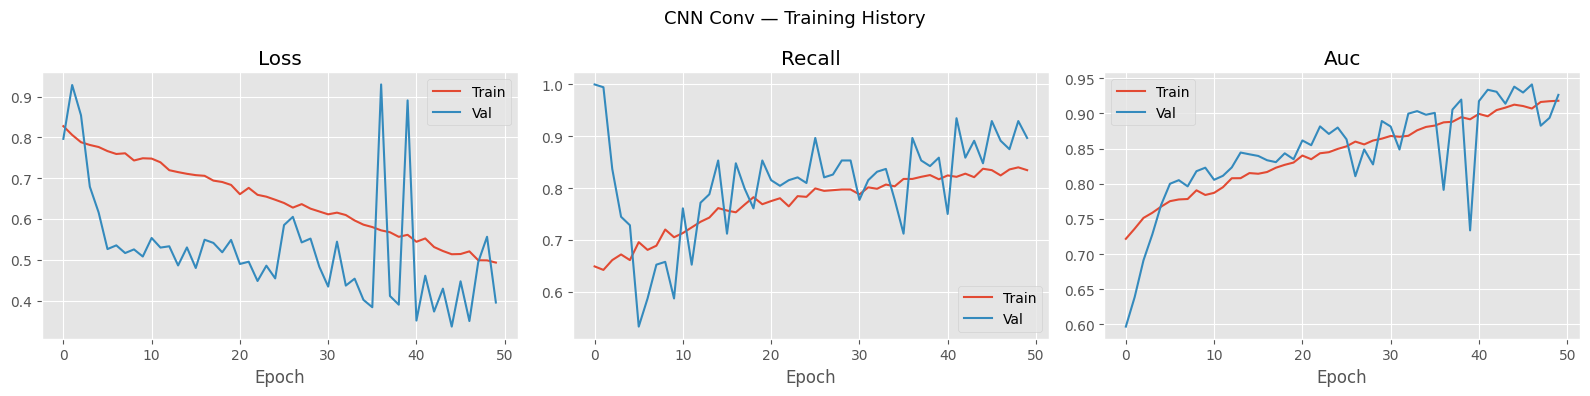

In [ ]:
# --- Training curves ---

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("CNN Conv — Training History", fontsize=13)

for ax, metric in zip(axes, ["loss", "recall", "auc"]):
    ax.plot(history_conv.history[metric], label="Train")
    ax.plot(history_conv.history[f"val_{metric}"], label="Val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

### Evaluate



  CNN Conv — Test Set Evaluation
              precision    recall  f1-score   support

No Oil Spill       0.95      0.79      0.86       370
   Oil Spill       0.69      0.91      0.78       184

    accuracy                           0.83       554
   macro avg       0.82      0.85      0.82       554
weighted avg       0.86      0.83      0.84       554



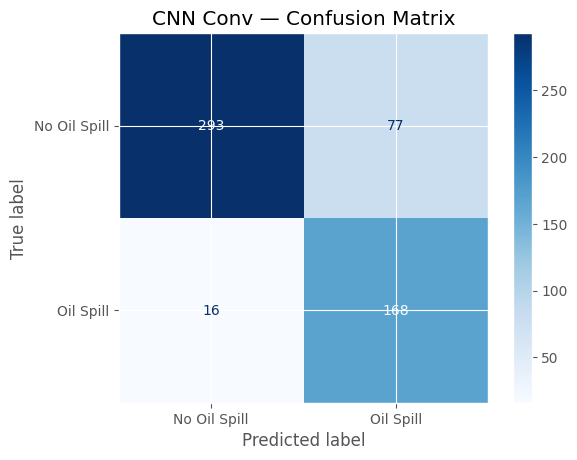

In [ ]:
y_true_conv, y_prob_conv = evaluate_model(cnn_conv, test_ds, "CNN Conv")

## 4.2 Model 2 - CNN with Residual blocks


In [113]:
# --- Residual Block ---
def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)

    # 1x1 conv on shortcut if filter size changes
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


# --- Build CNN Res ---
def build_cnn_res(input_shape=(400, 400, 1)):
    inputs = layers.Input(shape=input_shape)

    # Initial conv
    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Residual blocks
    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)

    x = residual_block(x, 256)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="CNN_Res")


cnn_res = build_cnn_res()
cnn_res.summary()

Model: "CNN_Res"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 400, 400,  │        320 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 400,  │        128 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_40 (ReLU)     │ (None, 400, 400,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_28    │ (None, 200, 200,  │          0 │ re_lu_40[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 200, 200,  │     18,496 │ max_pooling2d_28… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 200,  │        256 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_41 (ReLU)     │ (None, 200, 200,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 200, 200,  │     36,928 │ re_lu_41[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 200, 200,  │      2,112 │ max_pooling2d_28… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 200,  │        256 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 200,  │        256 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 200, 200,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_42 (ReLU)     │ (None, 200, 200,  │          0 │ add_12[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_29    │ (None, 100, 100,  │          0 │ re_lu_42[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 100, 100,  │     73,856 │ max_pooling2d_29… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        512 │ conv2d_56[0][0] 

 Total params: 1,244,417 (4.75 MB)

 Trainable params: 1,241,665 (4.74 MB)

 Non-trainable params: 2,752 (10.75 KB)

### Compile


In [ ]:
cnn_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
    ],
)

### Train


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=7, restore_best_weights=True, monitor="val_auc_pr"
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "cnn_res_best.keras", save_best_only=True, monitor="val_auc_pr"
    ),
    StopLogger(),
]

history_res = cnn_res.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 33s 140ms/step - accuracy: 0.6597 - auc_pr: 0.5315 - auc_roc: 0.7106 - loss: 0.8536 - precision: 0.4919 - recall: 0.6590 - val_accuracy: 0.3321 - val_auc_pr: 0.3610 - val_auc_roc: 0.5794 - val_loss: 0.7745 - val_precision: 0.3321 - val_recall: 1.0000
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.6780 - auc_pr: 0.5688 - auc_roc: 0.7438 - loss: 0.7994 - precision: 0.5126 - recall: 0.6746 - val_accuracy: 0.3321 - val_auc_pr: 0.4525 - val_auc_roc: 0.6264 - val_loss: 0.9110 - val_precision: 0.3321 - val_recall: 1.0000
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7136 - auc_pr: 0.6020 - auc_roc: 0.7713 - loss: 0.7751 - precision: 0.5548 - recall: 0.7098 - val_accuracy: 0.4477 - val_auc_pr: 0.5298 - val_auc_roc: 0.6904 - val_loss: 0.8123 - val_precision: 0.3656 - val_recall: 0.9022
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7310 - auc_pr: 0.6276 - auc_roc: 0.7863 - loss: 0.7484 - prec

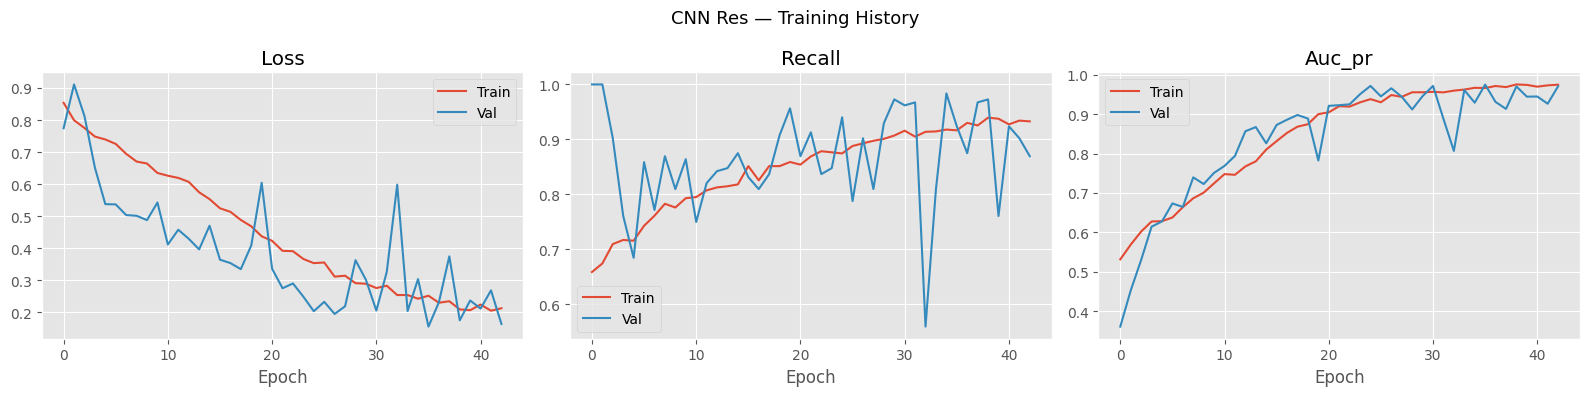

In [116]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("CNN Res — Training History", fontsize=13)

for ax, metric in zip(axes, ["loss", "recall", "auc_pr"]):
    ax.plot(history_res.history[metric], label="Train")
    ax.plot(history_res.history[f"val_{metric}"], label="Val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

### Evaluate



  CNN Res — Test Set Evaluation
              precision    recall  f1-score   support

No Oil Spill       0.96      0.94      0.95       370
   Oil Spill       0.89      0.93      0.91       184

    accuracy                           0.94       554
   macro avg       0.92      0.93      0.93       554
weighted avg       0.94      0.94      0.94       554



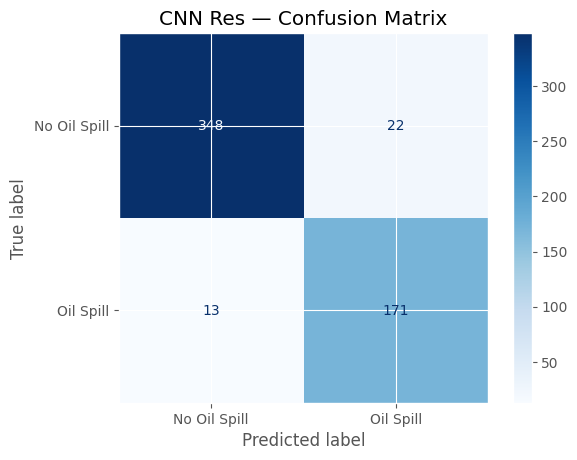

In [117]:
y_true_res, y_prob_res = evaluate_model(cnn_res, test_ds, "CNN Res")

## 4.3 Model 3 : Building CNN RES SE Model


In [ ]:
# SE Squeeze and Excitation block function
def se_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)

    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])


# Residual + SE Block
def residual_se_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)

    # SE attention
    x = se_block(x)

    # 1x1 conv on shortcut if filter size changes
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


# Build CNN Res SE Model
def build_cnn_res_se(input_shape=(400, 400, 1)):
    inputs = layers.Input(shape=input_shape)

    # Initial conv
    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Residual SE blocks
    x = residual_se_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)

    x = residual_se_block(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)

    x = residual_se_block(x, 256)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="CNN_Res_SE")


cnn_res_se = build_cnn_res_se()
cnn_res_se.summary()

Model: "CNN_Res_SE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 400, 400,  │        320 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 400,  │        128 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_47 (ReLU)     │ (None, 400, 400,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 200, 200,  │          0 │ re_lu_47[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 200, 200,  │     18,496 │ max_pooling2d_32… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 200,  │        256 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_48 (ReLU)     │ (None, 200, 200,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 200, 200,  │     36,928 │ re_lu_48[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 200,  │        256 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │        320 │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 200, 200,  │      2,112 │ max_pooling2d_32… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 200, 200,  │          0 │ batch_normalizat… │
│ (Multiply)          │ 64)               │            │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 200,  │        256 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 200, 200,  │          0 │ multiply_6[0][0]

 Total params: 1,255,645 (4.79 MB)

 Trainable params: 1,252,893 (4.78 MB)

 Non-trainable params: 2,752 (10.75 KB)

### Compile


In [ ]:
cnn_res_se.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
    ],
)

### Train


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=7, restore_best_weights=True, monitor="val_auc_pr"
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "cnn_res_se_best.keras", save_best_only=True, monitor="val_auc_pr"
    ),
    StopLogger(),
]

history_res_se = cnn_res_se.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step - accuracy: 0.6430 - auc_pr: 0.5167 - auc_roc: 0.7059 - loss: 0.8486 - precision: 0.4743 - recall: 0.6644 - val_accuracy: 0.3321 - val_auc_pr: 0.3753 - val_auc_roc: 0.5990 - val_loss: 0.8487 - val_precision: 0.3321 - val_recall: 1.0000
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6816 - auc_pr: 0.5743 - auc_roc: 0.7499 - loss: 0.7967 - precision: 0.5166 - recall: 0.6854 - val_accuracy: 0.4043 - val_auc_pr: 0.3869 - val_auc_roc: 0.6063 - val_loss: 0.8662 - val_precision: 0.3546 - val_recall: 0.9674
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.7035 - auc_pr: 0.5776 - auc_roc: 0.7610 - loss: 0.7815 - precision: 0.5442 - recall: 0.6766 - val_accuracy: 0.4928 - val_auc_pr: 0.5480 - val_auc_roc: 0.6786 - val_loss: 0.7550 - val_precision: 0.3772 - val_recall: 0.8098
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.7053 - auc_pr: 0.6036 - auc_roc: 0.7742 - loss: 0.7612 - prec

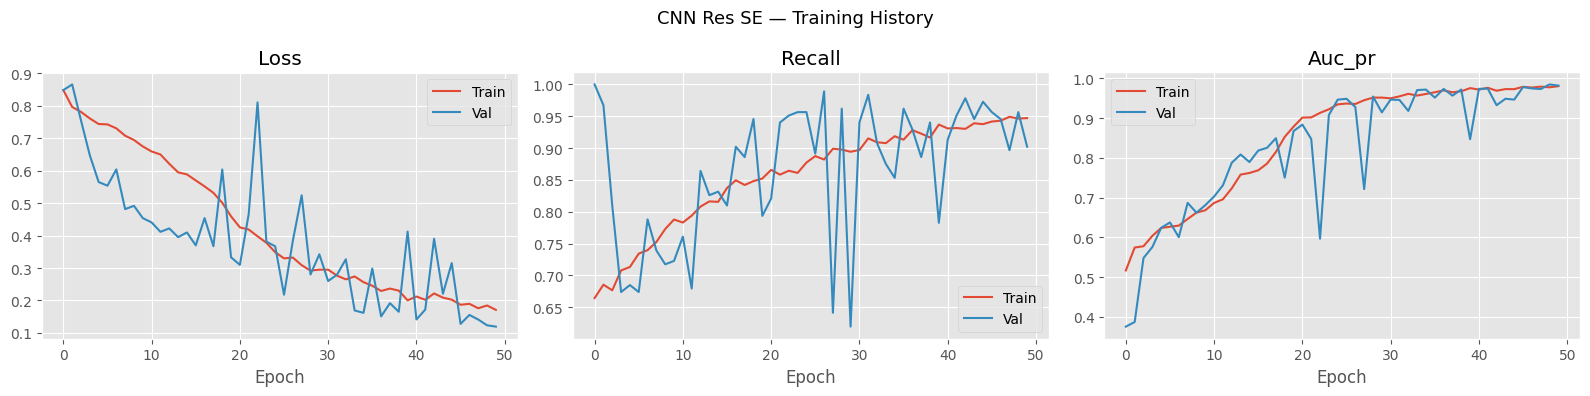

In [121]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("CNN Res SE — Training History", fontsize=13)

for ax, metric in zip(axes, ["loss", "recall", "auc_pr"]):
    ax.plot(history_res_se.history[metric], label="Train")
    ax.plot(history_res_se.history[f"val_{metric}"], label="Val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

### Evaluate



  CNN Res SE — Test Set Evaluation
              precision    recall  f1-score   support

No Oil Spill       0.97      0.95      0.96       370
   Oil Spill       0.90      0.95      0.93       184

    accuracy                           0.95       554
   macro avg       0.94      0.95      0.94       554
weighted avg       0.95      0.95      0.95       554



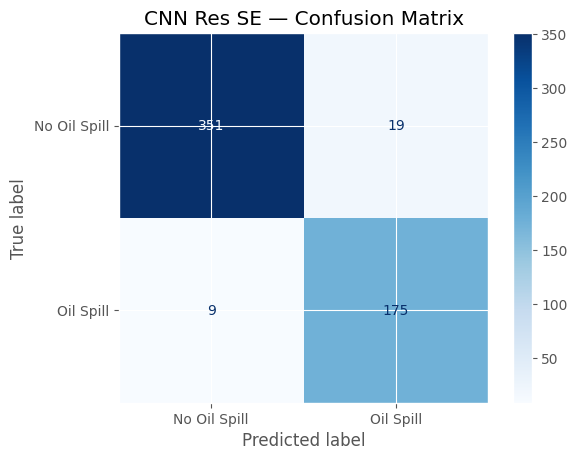

In [122]:
y_true_res_se, y_prob_res_se = evaluate_model(cnn_res_se, test_ds, "CNN Res SE")

## 4.4 Baseline model: EfficientNet


### build & compile


In [ ]:
def build_efficientnet(input_shape=(400, 400, 1)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Rescaling(255.0)(inputs)
    x = layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1))(x)

    base = EfficientNetB0(
        weights="imagenet", include_top=False, input_shape=(400, 400, 3)
    )
    base.trainable = False  # Fully frozen — pure feature extraction

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="EfficientNetB0_baseline")


model = build_efficientnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
    ],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor="val_auc_pr"
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "efficientnet_best.keras", save_best_only=True, monitor="val_auc_pr"
    ),
    StopLogger(),
]

history_eff = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 50s 205ms/step - accuracy: 0.7633 - auc_pr: 0.7732 - auc_roc: 0.8464 - loss: 0.6791 - precision: 0.6232 - recall: 0.7322 - val_accuracy: 0.8845 - val_auc_pr: 0.9013 - val_auc_roc: 0.9396 - val_loss: 0.3452 - val_precision: 0.8750 - val_recall: 0.7609
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8564 - auc_pr: 0.8877 - auc_roc: 0.9268 - loss: 0.4867 - precision: 0.7532 - recall: 0.8461 - val_accuracy: 0.8845 - val_auc_pr: 0.9284 - val_auc_roc: 0.9598 - val_loss: 0.3002 - val_precision: 0.7941 - val_recall: 0.8804
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8801 - auc_pr: 0.9034 - auc_roc: 0.9410 - loss: 0.4295 - precision: 0.7928 - recall: 0.8664 - val_accuracy: 0.9025 - val_auc_pr: 0.9436 - val_auc_roc: 0.9695 - val_loss: 0.2697 - val_precision: 0.8218 - val_recall: 0.9022
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8972 - auc_pr: 0.9270 - auc_roc: 0.9540 - loss: 0.3825 - precisi

### Evaluate



  EfficientNetB0 — Test Set Evaluation
              precision    recall  f1-score   support

No Oil Spill       0.98      0.93      0.96       370
   Oil Spill       0.88      0.96      0.92       184

    accuracy                           0.94       554
   macro avg       0.93      0.95      0.94       554
weighted avg       0.95      0.94      0.94       554



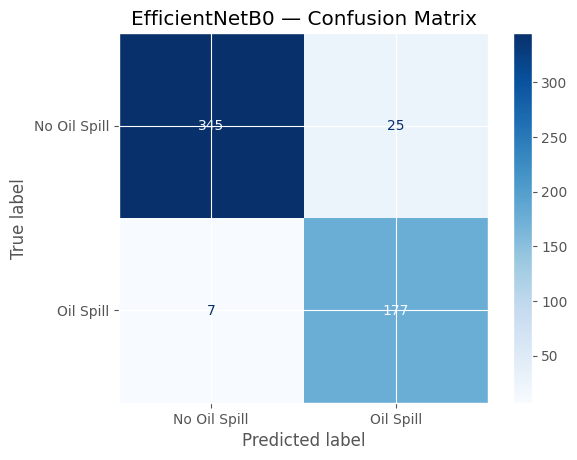

In [124]:
y_true_eff, y_prob_eff = evaluate_model(model, test_ds, "EfficientNetB0")

# 5.Compare Models


In [ ]:
results = {}
for name, y_true, y_prob in [
    ("CNN Conv", y_true_conv, y_prob_conv),
    ("CNN Res", y_true_res, y_prob_res),
    ("CNN Res SE", y_true_res_se, y_prob_res_se),
    ("EfficientNet", y_true_eff, y_prob_eff),
]:
    y_pred = (np.array(y_prob) > 0.5).astype(int)
    f1s = f1_score(y_true, y_pred, average=None)
    results[name] = {
        "F1 Macro": round(f1_score(y_true, y_pred, average="macro"), 4),
        "F1 No Oil": round(f1s[0], 4),
        "F1 Oil": round(f1s[1], 4),
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
    }

summary_df = pd.DataFrame(results).T.sort_values("F1 Macro", ascending=False)
print(summary_df.to_string())

              F1 Macro  F1 No Oil  F1 Oil  AUC-ROC
CNN Res SE      0.9438     0.9616  0.9259   0.9830
EfficientNet    0.9364     0.9557  0.9171   0.9893
CNN Res         0.9296     0.9521  0.9072   0.9775
CNN Conv        0.8231     0.8630  0.7832   0.9382


Last conv layer: conv2d_71


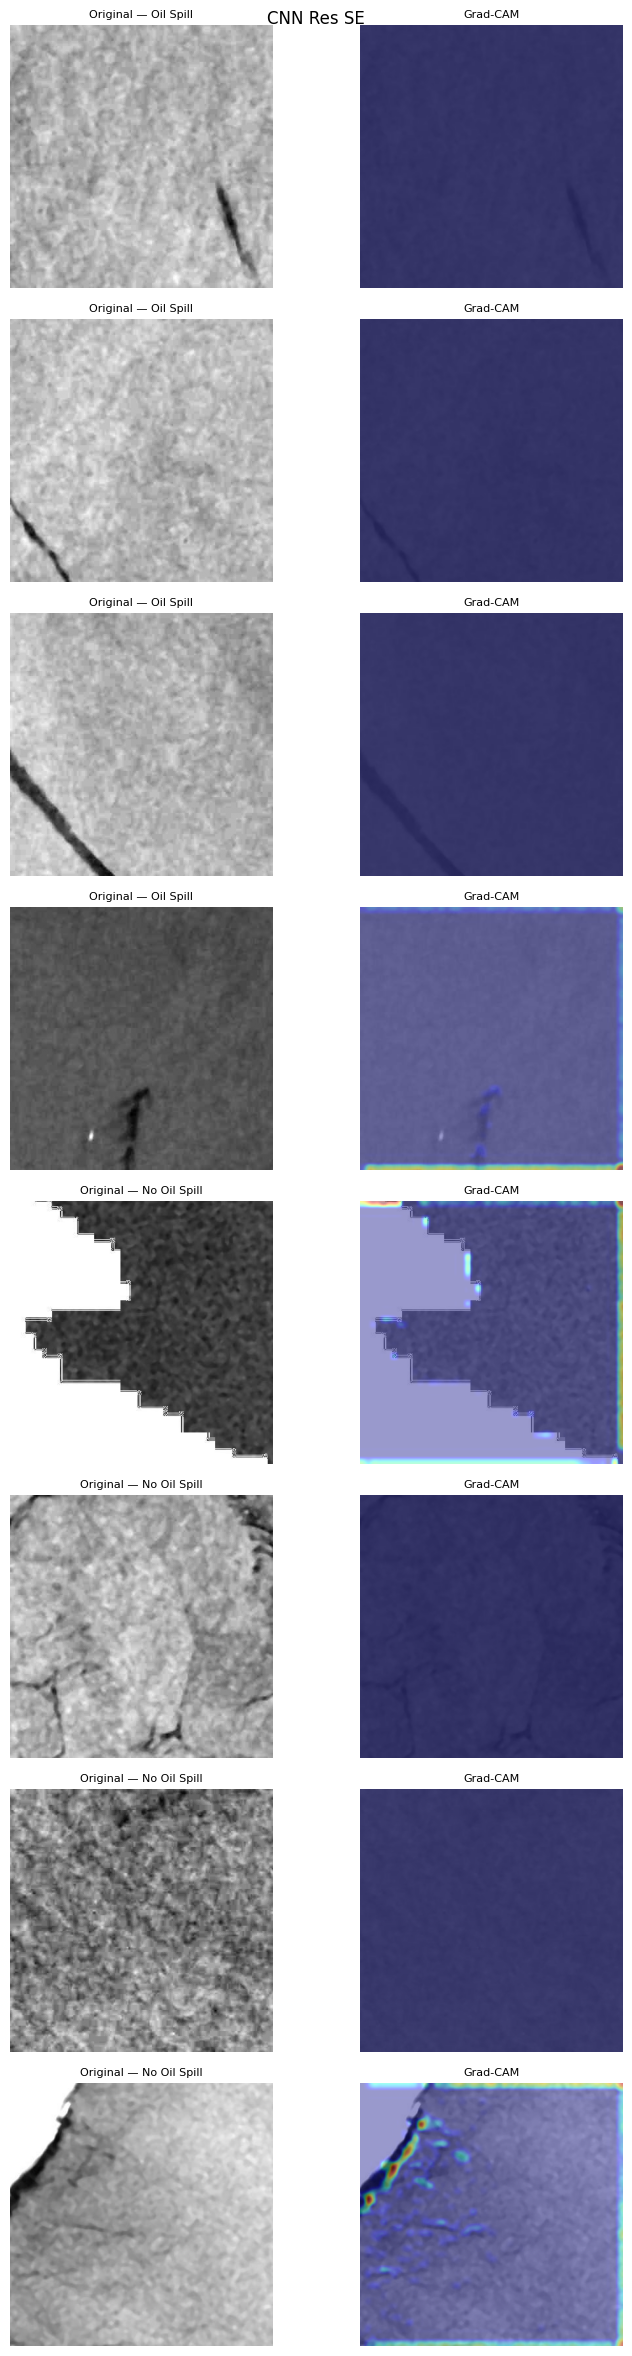

In [ ]:
def get_gradcam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def show_gradcam(model, filepaths, labels, last_conv, title):
    fig, axes = plt.subplots(len(filepaths), 2, figsize=(8, 3 * len(filepaths)))
    fig.suptitle(title, fontsize=12)
    for i, (fp, lbl) in enumerate(zip(filepaths, labels)):
        arr = np.array(Image.open(fp).convert("L"), dtype=np.float32) / 255.0
        inp = arr[np.newaxis, :, :, np.newaxis]
        heat = get_gradcam(model, inp, last_conv)
        heat_up = np.array(
            Image.fromarray((heat * 255).astype(np.uint8)).resize(
                (arr.shape[1], arr.shape[0]), Image.LANCZOS
            )
        )
        color = plt.cm.jet(heat_up / 255.0)[:, :, :3]
        overlay = (0.4 * color * 255 + 0.6 * np.stack([arr * 255] * 3, axis=-1)).astype(
            np.uint8
        )

        axes[i, 0].imshow(arr, cmap="gray")
        axes[i, 0].set_title(f"Original — {lbl}", fontsize=8)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title("Grad-CAM", fontsize=8)
        axes[i, 1].axis("off")
    plt.tight_layout()
    plt.savefig(f"gradcam_{title.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Find last Conv2D layer in CNN Res SE
last_conv = next(
    l.name for l in reversed(cnn_res_se.layers) if isinstance(l, tf.keras.layers.Conv2D)
)
print("Last conv layer:", last_conv)

# Run on 4 images per class for test set
oil_fps = test_df[test_df["label"] == 1]["filepath"].sample(4, random_state=1).tolist()
no_oil_fps = (
    test_df[test_df["label"] == 0]["filepath"].sample(4, random_state=1).tolist()
)

show_gradcam(
    cnn_res_se,
    oil_fps + no_oil_fps,
    ["Oil Spill"] * 4 + ["No Oil Spill"] * 4,
    last_conv,
    "CNN Res SE",
)